In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
df_train = pd.read_csv('train.csv')

In [48]:
df_train.drop(['id','num_lanes','time_of_day'],axis=1,inplace=True)

In [49]:
df_train = df_train.head(1000).reset_index(drop=True).copy()

In [50]:
print("--- Task 1.1: Data Dimensions ---")
print(f"The dataset has {df_train.shape[0]} rows and {df_train.shape[1]} columns.")

print("--- Task 1.2: Data Types and Info ---")
# This command prints the data types, non-null counts, and memory usage.
# This is the MOST IMPORTANT output for this lab.
df_train.info()
print("\n")

print("--- Task 1.3: First 5 Rows ---")
# This helps you visually inspect the columns
df_train.head()

--- Task 1.1: Data Dimensions ---
The dataset has 1000 rows and 11 columns.
--- Task 1.2: Data Types and Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   road_type               1000 non-null   object 
 1   curvature               1000 non-null   float64
 2   speed_limit             1000 non-null   int64  
 3   lighting                1000 non-null   object 
 4   weather                 1000 non-null   object 
 5   road_signs_present      1000 non-null   bool   
 6   public_road             1000 non-null   bool   
 7   holiday                 1000 non-null   bool   
 8   school_season           1000 non-null   bool   
 9   num_reported_accidents  1000 non-null   int64  
 10  accident_risk           1000 non-null   float64
dtypes: bool(4), float64(2), int64(2), object(3)
memory usage: 58.7+ KB


--- Task 1.3: Fir

,road_type,curvature,speed_limit,lighting,weather,road_signs_present,public_road,holiday,school_season,num_reported_accidents,accident_risk
0,urban,0.06,35,daylight,rainy,False,True,False,True,1,0.13
1,urban,0.99,35,daylight,clear,True,False,True,True,0,0.35
2,rural,0.63,70,dim,clear,False,True,True,False,2,0.30
3,highway,0.07,35,dim,rainy,True,True,False,False,1,0.21
4,rural,0.58,60,daylight,foggy,False,False,True,False,1,0.56


## Lab 2

In [51]:
# create copies so original dfs remain available
df_train_missing = df_train.copy()

# reproducible random selection
rng = np.random.RandomState(42)

# specify fraction of missing values to inject per column
missing_config = {
    'curvature': 0.02,           # 2% missing (numeric)
    'lighting': 0.05,            # 5% missing (categorical)
    'weather': 0.03,             # 3% missing (categorical)
    'road_signs_present': 0.01,  # 1% missing (boolean -> will become object/float after NaN)
    # 'accident_risk': 0.04        # 4% missing (numeric target/score)
    # 'curvature' : 0.02,           # 2% missing (numeric)
}

# helper to inject missing values into a dataframe
def inject_missing(df, config, rng):
    n_rows = len(df)
    for col, frac in config.items():
        n_missing = int(np.floor(frac * n_rows))
        if n_missing <= 0:
            continue
        idx = rng.choice(df.index, size=n_missing, replace=False)
        df.loc[idx, col] = np.nan
    return df

# inject into full training set and sample (use different RNG states for variety)
# df_train_missing = inject_missing(df_train_missing, missing_config, np.random.RandomState(42))
df_train_missing = inject_missing(df_train_missing, missing_config, np.random.RandomState(7))

# quick check of introduced missing values
# print("Missing counts in df_train_missing:")
# print(df_train_missing.isnull().sum())
print("\nMissing counts in df_train_missing:")
print(df_train_missing.isnull().sum())


Missing counts in df_train_missing:
road_type                  0
curvature                 20
speed_limit                0
lighting                  50
weather                   30
road_signs_present        10
public_road                0
holiday                    0
school_season              0
num_reported_accidents     0
accident_risk              0
dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_9864\1434432488.py:25: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[idx, col] = np.nan


In [52]:
# We assume 'df_train_missing' exists from your previous code.
# Create a copy to work on
df_imputed = df_train_missing.copy()

# --- 1. Impute NUMERIC columns (using MEDIAN) ---
# List of numeric columns you made missing
num_missing_cols = ['curvature'] 

for col in num_missing_cols:
    median_val = df_imputed[col].median()
    df_imputed[col] = df_imputed[col].fillna(median_val)
    print(f"Imputed missing '{col}' values with median: {median_val}")

# --- 2. Impute CATEGORICAL/BOOLEAN columns (using MODE) ---
# List of categorical/boolean columns you made missing
cat_missing_cols = ['lighting', 'weather', 'road_signs_present']

for col in cat_missing_cols:
    mode_val = df_imputed[col].mode()[0]
    df_imputed[col] = df_imputed[col].fillna(mode_val)
    print(f"Imputed missing '{col}' values with mode: {mode_val}")

# --- 3. Final Check ---
# print("\n--- Task 1.1: Missing Value Check After Imputation ---")
print(df_imputed.isnull().sum())

# print("\n--- Task 1.2: Data Types After Imputation ---")
print(df_imputed.info())

Imputed missing 'curvature' values with median: 0.49
Imputed missing 'lighting' values with mode: dim
Imputed missing 'weather' values with mode: clear
Imputed missing 'road_signs_present' values with mode: False
road_type                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   road_type               1000 non-null   object 
 1   curvature               1000 non-null   float64
 2   speed_limit             1000 non-null   int64  
 3   lighting                1000 non-null   object 
 4   weather                 1000 non-null

C:\Users\ASUS\AppData\Local\Temp\ipykernel_9864\3494326016.py:20: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_imputed[col] = df_imputed[col].fillna(mode_val)


In [53]:
from sklearn.preprocessing import StandardScaler

# We assume 'df_imputed' exists from the previous block
df_encoded = df_imputed.copy()

# List of categorical columns to encode (from Lab 1)
categorical_cols = ['road_type', 'lighting', 'weather']

# print(f"--- Task 2.1: Encoding Categorical Columns ---")
print(f"Original shape: {df_encoded.shape}")
print(f"Columns to encode: {categorical_cols}")

# Perform one-hot encoding
# drop_first=True helps avoid multicollinearity (dummy variable trap)
df_encoded = pd.get_dummies(df_encoded, columns=categorical_cols, drop_first=True)

print(f"New shape after encoding: {df_encoded.shape}")
# print("\n--- First 5 Rows of Encoded Data ---")
print(df_encoded.head())

df_scaled = df_encoded.copy()

numeric_features = ['curvature', 'speed_limit', 'num_reported_accidents']

# print(f"--- Task 3.1: Scaling Numeric Features ---")
print(f"Columns to scale: {numeric_features}")

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform only the numeric feature columns
df_scaled[numeric_features] = scaler.fit_transform(df_scaled[numeric_features])

# print("\n--- Data Description After Scaling ---")
# .describe() is a great way to check
# Mean should be ~0 and std dev ~1 for the scaled columns
df_scaled[numeric_features].describe()

Original shape: (1000, 11)
Columns to encode: ['road_type', 'lighting', 'weather']
New shape after encoding: (1000, 14)
   curvature  speed_limit  road_signs_present  public_road  holiday  \
0       0.06           35               False         True    False   
1       0.99           35                True        False     True   
2       0.63           70               False         True     True   
3       0.07           35                True         True    False   
4       0.58           60               False        False     True   

   school_season  num_reported_accidents  accident_risk  road_type_rural  \
0           True                       1           0.13            False   
1           True                       0           0.35            False   
2          False                       2           0.30             True   
3          False                       1           0.21            False   
4          False                       1           0.56             True 

,curvature,speed_limit,num_reported_accidents
count,1.000000e+03,1.000000e+03,1.000000e+03
mean,-1.527667e-16,-1.705303e-16,1.101341e-16
std,1.000500e+00,1.000500e+00,1.000500e+00
min,-1.750328e+00,-1.385391e+00,-1.271429e+00
25%,-8.568492e-01,-7.593673e-01,-1.271429e+00
50%,7.385834e-02,-1.333431e-01,-1.753695e-01
75%,7.811961e-01,8.056930e-01,9.206896e-01
max,1.972502e+00,1.431717e+00,4.208867e+00


In [54]:
print(df_scaled[numeric_features].describe())

          curvature   speed_limit  num_reported_accidents
count  1.000000e+03  1.000000e+03            1.000000e+03
mean  -1.527667e-16 -1.705303e-16            1.101341e-16
std    1.000500e+00  1.000500e+00            1.000500e+00
min   -1.750328e+00 -1.385391e+00           -1.271429e+00
25%   -8.568492e-01 -7.593673e-01           -1.271429e+00
50%    7.385834e-02 -1.333431e-01           -1.753695e-01
75%    7.811961e-01  8.056930e-01            9.206896e-01
max    1.972502e+00  1.431717e+00            4.208867e+00



--- Task 4.1: Pearson's Correlation Heatmap ---
Heatmap saved as: lab2_pearson_heatmap.png


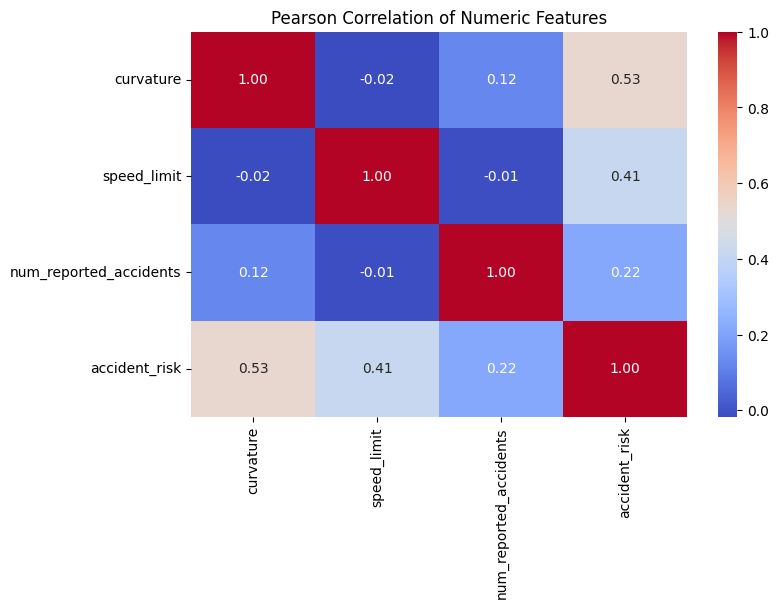

In [55]:
from scipy.spatial.distance import cosine, jaccard
from sklearn.metrics import euclidean_distances

# We assume 'df_scaled' exists from the previous block
# and 'numeric_features' list is defined

# Add accident_risk to numeric features for correlation analysis
numeric_features.append('accident_risk')
# --- 1. Pearson's Correlation ---
print("\n--- Task 4.1: Pearson's Correlation Heatmap ---")
plt.figure(figsize=(8, 5))

# Calculate correlation matrix for numeric features
corr_matrix = df_scaled[numeric_features].corr(method='pearson')

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Pearson Correlation of Numeric Features')
plot_filename = 'lab2_pearson_heatmap.png'
plt.savefig(plot_filename)
print(f"Heatmap saved as: {plot_filename}")
plt.show()

In [56]:
# --- 2. Similarity/Distance (between SAMPLES) ---
print("\n--- Task 4.2: Sample Similarity/Distance Matrices (Sample vs. Sample) ---")

# Helper functions as you provided
def cosine_sim(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def euc_dist(a, b):
    return np.linalg.norm(a - b)

def jaccard(a, b):
    intersection = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return intersection / union if union != 0 else 1.0

# --- Cosine & Euclidean ---
# We use the scaled numeric features for this
data_numeric = df_scaled[numeric_features].values

print("\nCosine Similarity (first 5x5):")
cosine_matrix = np.array([[cosine_sim(data_numeric[i], data_numeric[j]) for j in range(5)] for i in range(5)])
print(cosine_matrix)

print("\nEuclidean Distance (first 5x5):")
euc_matrix = np.array([[euc_dist(data_numeric[i], data_numeric[j]) for j in range(5)] for i in range(5)]) 
print(euc_matrix)

# --- Jaccard Similarity ---
# We create the binary "basket" based on your logic
# We apply it to the scaled numeric features
basket = (df_scaled[numeric_features] > df_scaled[numeric_features].median()).astype(int).values

print("\nJaccard Similarity (first 5x5):")
jaccard_matrix = np.array([[jaccard(basket[i], basket[j]) for j in range(5)] for i in range(5)])
print(jaccard_matrix)

print("\n--- Processed Data Preview (Head) ---")
# This provides context for the similarity matrices
print(df_scaled.head())


--- Task 4.2: Sample Similarity/Distance Matrices (Sample vs. Sample) ---

Cosine Similarity (first 5x5):
[[ 1.         -0.49849651 -0.67400647  0.99877029 -0.61149421]
 [-0.49849651  1.         -0.22247109 -0.48184704  0.22565291]
 [-0.67400647 -0.22247109  1.         -0.66902291  0.71259311]
 [ 0.99877029 -0.48184704 -0.66902291  1.         -0.58761016]
 [-0.61149421  0.22565291  0.71259311 -0.58761016  1.        ]]

Euclidean Distance (first 5x5):
[[0.         3.63824077 3.24561801 0.08823801 2.5262448 ]
 [3.63824077 0.         3.37711703 3.59883256 2.45451322]
 [3.24561801 3.37711703 0.         3.21817096 1.30211381]
 [0.08823801 3.59883256 3.21817096 0.         2.4853089 ]
 [2.5262448  2.45451322 1.30211381 2.4853089  0.        ]]

Jaccard Similarity (first 5x5):
[[1.         0.         0.         1.         0.        ]
 [0.         1.         0.33333333 0.         0.33333333]
 [0.         0.33333333 1.         0.         0.5       ]
 [1.         0.         0.         1.         

--- Task 1.1: Plotting Numeric Distributions ---
Numeric distributions plot saved as: lab3_numeric_distributions.png


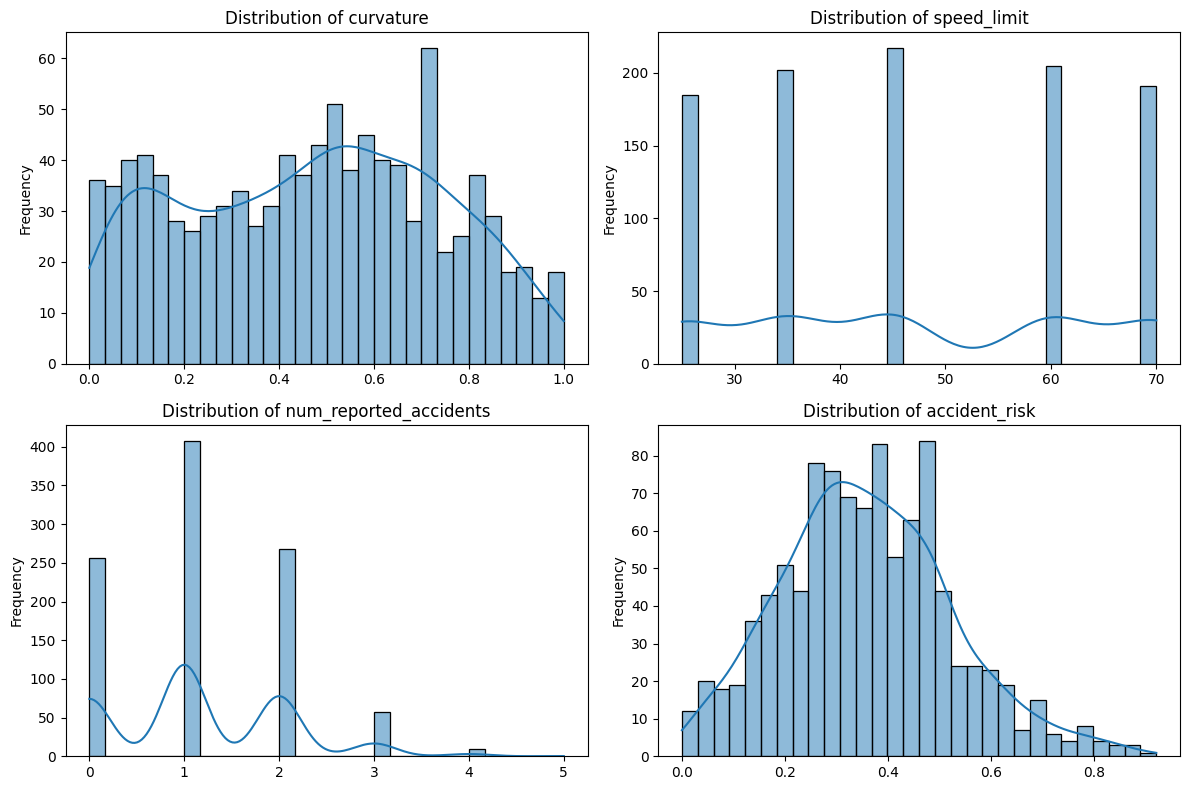


--- Task 1.2: Plotting Categorical Distributions ---
Categorical distributions plot saved as: lab3_categorical_distributions.png


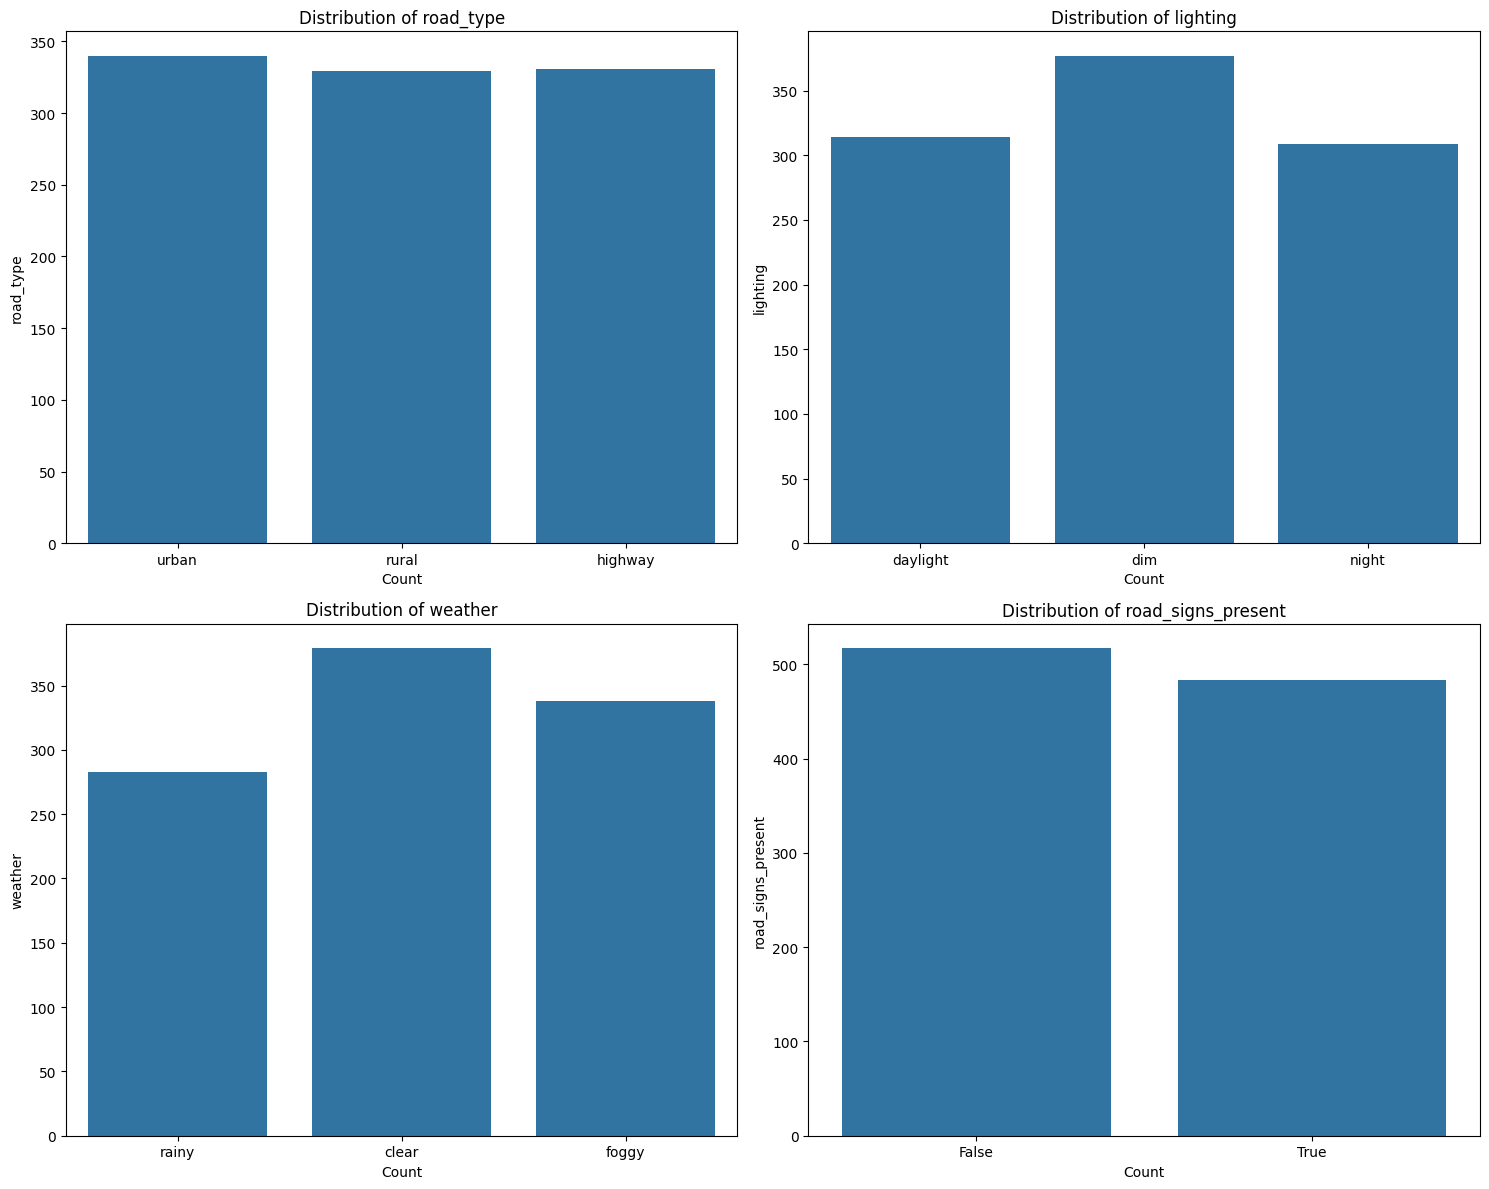

In [57]:
# We assume 'df_imputed' exists from Lab 2
# (This is the data *after* filling missing values, but *before* encoding/scaling)

# --- 1.A: Distributions for NUMERIC Features ---
# List of your original numeric features + the label
numeric_cols = ['curvature', 'speed_limit', 'num_reported_accidents', 'accident_risk']

print("--- Task 1.1: Plotting Numeric Distributions ---")
plt.figure(figsize=(12, 8))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df_imputed[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel('')
    plt.ylabel('Frequency')

plt.tight_layout()
plot_filename_hist = 'lab3_numeric_distributions.png'
plt.savefig(plot_filename_hist)
print(f"Numeric distributions plot saved as: {plot_filename_hist}")
plt.show()


# --- 1.B: Distributions for CATEGORICAL Features ---
# List of your original categorical and boolean features
categorical_cols = [
    'road_type', 'lighting', 'weather', 'road_signs_present'
]

print("\n--- Task 1.2: Plotting Categorical Distributions ---")
plt.figure(figsize=(15, 12))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 2, i)  # Move subplot before plotting
    
    # For columns with many categories, get the top 10
    if df_imputed[col].nunique() > 10:
        top_categories = df_imputed[col].value_counts().nlargest(10).index
        sns.countplot(
            y=col, 
            data=df_imputed, 
            order=top_categories
        )
    else:
        # For columns with few categories, plot all
        sns.countplot(
            x=col, 
            data=df_imputed
        )
    
    plt.title(f'Distribution of {col}')
    plt.xlabel('Count')
    plt.ylabel(col)

plt.tight_layout()
plot_filename_cat = 'lab3_categorical_distributions.png'
plt.savefig(plot_filename_cat)
print(f"Categorical distributions plot saved as: {plot_filename_cat}")
plt.show()

--- Task 2.1: Plotting Boxplots for Outlier Detection ---
Boxplots saved as: lab3_boxplots.png


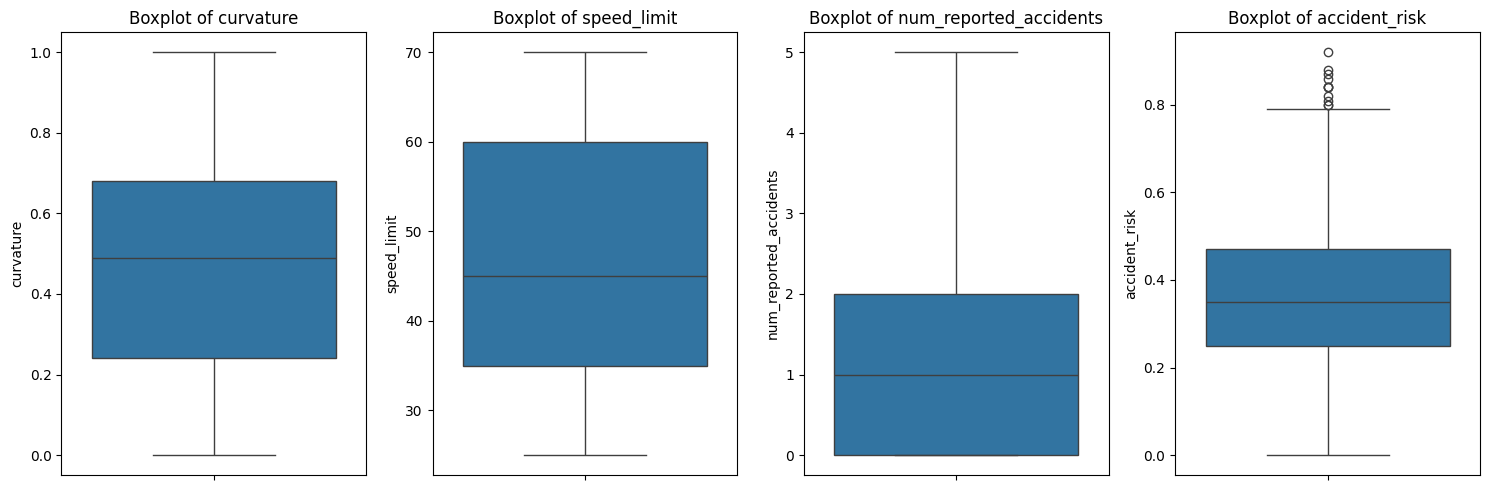

In [58]:
# We assume 'df_imputed' exists

# --- 2.A: Boxplots for NUMERIC Features ---
# We use the same numeric list as before
numeric_cols = ['curvature', 'speed_limit', 'num_reported_accidents', 'accident_risk']

print("--- Task 2.1: Plotting Boxplots for Outlier Detection ---")
plt.figure(figsize=(15, 5))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df_imputed[col])
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)

plt.tight_layout()
plot_filename_box = 'lab3_boxplots.png'
plt.savefig(plot_filename_box)
print(f"Boxplots saved as: {plot_filename_box}")
plt.show()

In [59]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier, plot_tree


In [60]:
# We assume 'df_scaled' exists from Lab 2.
# This df should contain all your preprocessed features AND the original 'accident_risk' column.
df_lab5 = df_scaled.copy()

# --- Task 1.1: Create Categorical Labels ---
# 'qcut' splits the data into 3 equal-sized bins (quantiles)
df_lab5['risk_category'] = pd.qcut(
    df_lab5['accident_risk'],
    q=3,
    labels=['low', 'medium', 'high']
)

print("--- Class Distribution ---")
print(df_lab5['risk_category'].value_counts())
print("\n")

--- Class Distribution ---
risk_category
low       345
high      332
medium    323
Name: count, dtype: int64




In [61]:
df_lab5.drop('accident_risk', axis=1, inplace=True)

In [62]:
df_lab5.head()

,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,num_reported_accidents,road_type_rural,road_type_urban,lighting_dim,lighting_night,weather_foggy,weather_rainy,risk_category
0,-1.526959,-0.759367,False,True,False,True,-0.175369,False,True,False,False,False,True,low
1,1.935273,-0.759367,True,False,True,True,-1.271429,False,True,False,False,False,False,medium
2,0.595055,1.431717,False,True,True,False,0.920690,True,False,True,False,False,False,medium
3,-1.489730,-0.759367,True,True,False,False,-0.175369,False,False,True,False,False,True,low
4,0.408913,0.805693,False,False,True,False,-0.175369,True,False,False,False,True,False,high


In [63]:
# --- Task 1.2: Split Data for Training/Testing ---

# 'X' is all columns EXCEPT our original target and new target
feature_columns = [
    col for col in df_lab5.columns if col not in ['risk_category']
]
X = df_lab5[feature_columns]

# 'y' is our new categorical label
y = df_lab5['risk_category']

# Use a standard 80% train, 20% test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # 'stratify' ensures train/test sets have similar class balance
)

print(f"--- Data Split ---")
print(f"Total samples: {len(X)}")
print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")

--- Data Split ---
Total samples: 1000
Training samples: 800
Test samples: 200


In [64]:

dt_classifier_gini = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4, 
    random_state=42
)

dt_classifier_gini.fit(X_train, y_train)

print("--- Decision Tree (Gini) Model Trained ---")


# --- Task 2.2: Compute Accuracy on Test Set ---
y_pred_gini = dt_classifier_gini.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_gini)
print(f"Test Set Accuracy (Gini): {accuracy:.4f}\n")

print("--- Classification Report (Gini) ---")
# This shows precision, recall, and f1-score for each class
print(classification_report(y_test, y_pred_gini))


--- Decision Tree (Gini) Model Trained ---
Test Set Accuracy (Gini): 0.7200

--- Classification Report (Gini) ---
              precision    recall  f1-score   support

        high       0.74      0.82      0.78        66
         low       0.86      0.72      0.79        69
      medium       0.58      0.62      0.60        65

    accuracy                           0.72       200
   macro avg       0.73      0.72      0.72       200
weighted avg       0.73      0.72      0.72       200




--- Saving Tree Visualization ---
Tree visualization saved as: lab5_decision_tree_gini.png


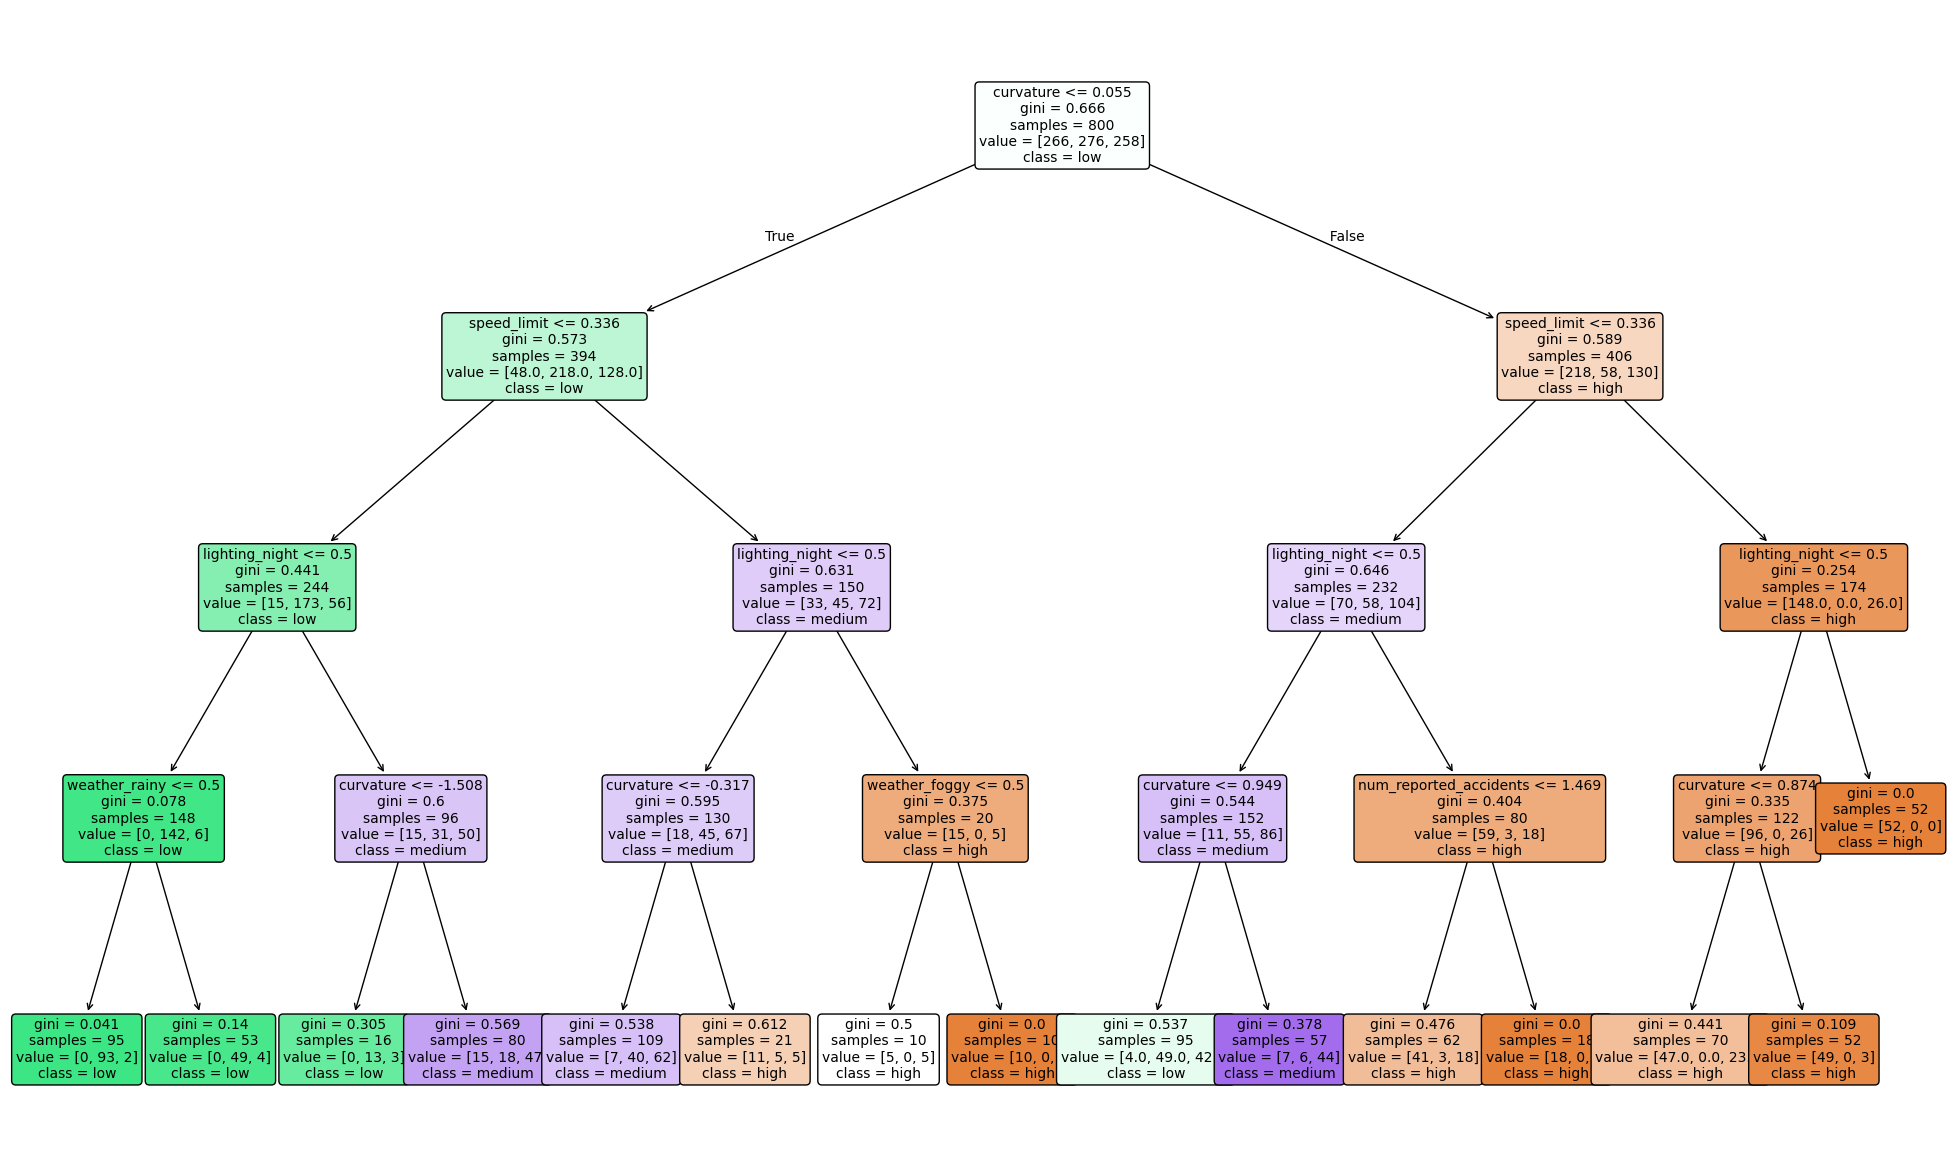

In [65]:
# --- Task 2.3: Visualize the Tree ---
print("\n--- Saving Tree Visualization ---")
plt.figure(figsize=(25, 15))
plot_tree(
    dt_classifier_gini,
    feature_names=X.columns.tolist(),
    class_names=['high', 'low', 'medium'], # Order MUST match model's classes_
    filled=True,
    rounded=True,
    fontsize=10
)

plot_filename_tree = 'lab5_decision_tree_gini.png'
plt.savefig(plot_filename_tree)
print(f"Tree visualization saved as: {plot_filename_tree}")
plt.show()

In [66]:
from sklearn.model_selection import cross_val_score, KFold

# --- Task 3.1: Cross-Validation ---
# We use a new, "full" (unconstrained) tree to assess its performance
full_dt_classifier = DecisionTreeClassifier(random_state=42)

# We use the *entire* X and y datasets
# 'KFold' shuffles and splits the data into 10 folds
kfold = KFold(n_splits=10, shuffle=True, random_state=42)

# 'cross_val_score' runs the 10-fold validation
# 'scoring='accuracy'' tells it what metric to measure
scores = cross_val_score(
    full_dt_classifier, 
    X, y, 
    cv=kfold, 
    scoring='accuracy'
)

print(f"--- 10-Fold Cross-Validation ---")
print(f"Individual fold scores: \n{scores}")
print("\n")
print(f"Mean Accuracy: {scores.mean():.4f}")
print(f"Std Deviation: {scores.std():.4f}")

--- 10-Fold Cross-Validation ---
Individual fold scores: 
[0.69 0.66 0.66 0.65 0.72 0.77 0.7  0.66 0.65 0.74]


Mean Accuracy: 0.6900
Std Deviation: 0.0397


In [67]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

In [68]:
X

,curvature,speed_limit,road_signs_present,public_road,holiday,school_season,num_reported_accidents,road_type_rural,road_type_urban,lighting_dim,lighting_night,weather_foggy,weather_rainy
0,-1.526959,-0.759367,False,True,False,True,-0.175369,False,True,False,False,False,True
1,1.935273,-0.759367,True,False,True,True,-1.271429,False,True,False,False,False,False
2,0.595055,1.431717,False,True,True,False,0.920690,True,False,True,False,False,False
3,-1.489730,-0.759367,True,True,False,False,-0.175369,False,False,True,False,False,True
4,0.408913,0.805693,False,False,True,False,-0.175369,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0.260000,-0.759367,False,True,False,True,-1.271429,False,False,False,True,True,False
996,-1.042991,-0.133343,False,False,True,True,-0.175369,False,False,True,False,False,False
997,-1.378045,1.431717,True,False,True,True,0.920690,False,False,True,False,False,True
998,-0.521794,0.805693,False,False,False,False,-1.271429,True,False,False,False,False,False


--- Task 1.1: Running Elbow Method ---
Completed K=2
Completed K=3
Completed K=4
Completed K=5
Completed K=6
Completed K=7
Completed K=8
Completed K=9
Completed K=10

Elbow plot saved as: lab6_elbow_plot.png


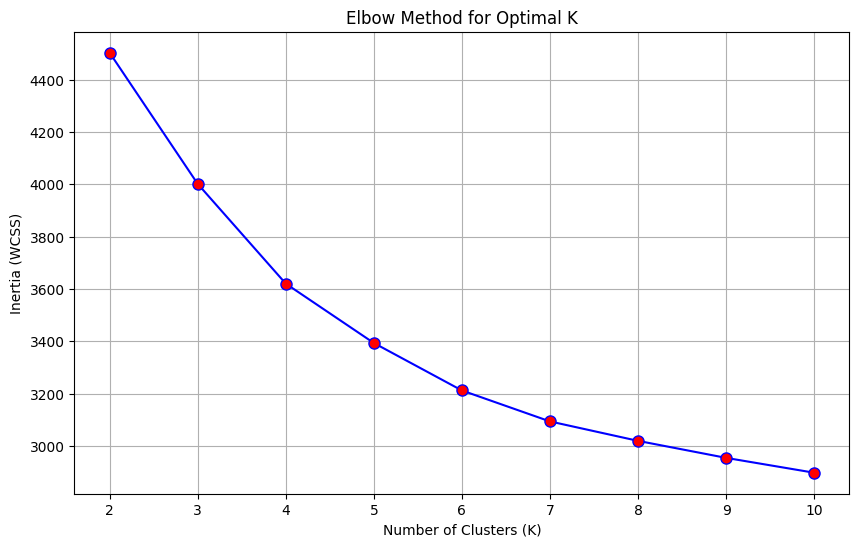

In [69]:
print("--- Task 1.1: Running Elbow Method ---")

# We will store the inertia for each K
inertia_values = []
k_range = range(2, 11) # Test K from 2 to 10

for k in k_range:
    kmeans = KMeans(
        n_clusters=k, 
        n_init=10,       # Run 10 times with different centroids
        random_state=42
    )
    kmeans.fit(X)
    inertia_values.append(kmeans.inertia_)
    print(f"Completed K={k}")

# --- Plot the Elbow Curve ---
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia_values, 'bo-', markerfacecolor='red', markersize=8)
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.xticks(k_range)
plt.grid(True)

plot_filename_elbow = 'lab6_elbow_plot.png'
plt.savefig(plot_filename_elbow)
print(f"\nElbow plot saved as: {plot_filename_elbow}")
plt.show()

--- Task 2.1: Running k-Means with K=4 ---
Silhouette Score for K=4: 0.1344

--- Task 2.2: Visualizing Clusters with PCA ---


c:\Users\ASUS\anaconda3\envs\py31013\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


Cluster visualization saved as: lab6_cluster_visualization.png


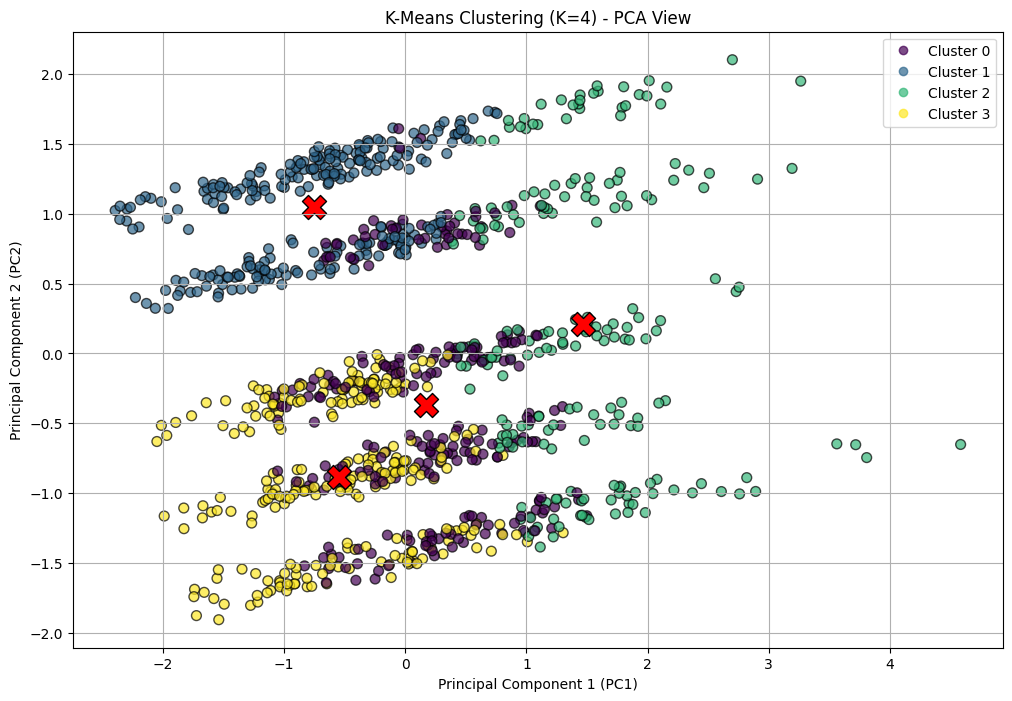

In [70]:
# --- PLEASE CHANGE THIS ---
# Look at your 'lab6_elbow_plot.png' and find the elbow.
# I am using 4 as a placeholder.
CHOSEN_K = 4
# -------------------------

print(f"--- Task 2.1: Running k-Means with K={CHOSEN_K} ---")

# --- 1. Run k-Means ---
kmeans_final = KMeans(
    n_clusters=CHOSEN_K,
    n_init=10,
    random_state=42
)
cluster_labels = kmeans_final.fit_predict(X)

# --- 2. Evaluate with Silhouette Score ---
score = silhouette_score(X, cluster_labels, random_state=42)
print(f"Silhouette Score for K={CHOSEN_K}: {score:.4f}")


# --- 3. Visualize Clusters using PCA ---
print("\n--- Task 2.2: Visualizing Clusters with PCA ---")
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X)

# Get cluster centers in the PCA space
centroids_pca = pca.transform(kmeans_final.cluster_centers_)

# --- 4. Plot the results ---
plt.figure(figsize=(12, 8))
scatter = plt.scatter(
    X_pca[:, 0], 
    X_pca[:, 1], 
    c=cluster_labels, 
    cmap='viridis',  # 'viridis' is a good color map
    alpha=0.7,
    edgecolors='k',
    s=50
)

# Plot the centroids
plt.scatter(
    centroids_pca[:, 0], 
    centroids_pca[:, 1],
    marker='X', 
    s=300,        # Make centroids bigger
    c='red',
    edgecolors='black',
    label='Centroids'
)

plt.title(f'K-Means Clustering (K={CHOSEN_K}) - PCA View')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(handles=scatter.legend_elements()[0], 
           labels=[f'Cluster {i}' for i in range(CHOSEN_K)])
plt.grid(True)

plot_filename_pca = 'lab6_cluster_visualization.png'
plt.savefig(plot_filename_pca)
print(f"Cluster visualization saved as: {plot_filename_pca}")
plt.show()

--- Task 3.1: Building Dendrogram ---
Dendrogram saved as: lab6_dendrogram.png


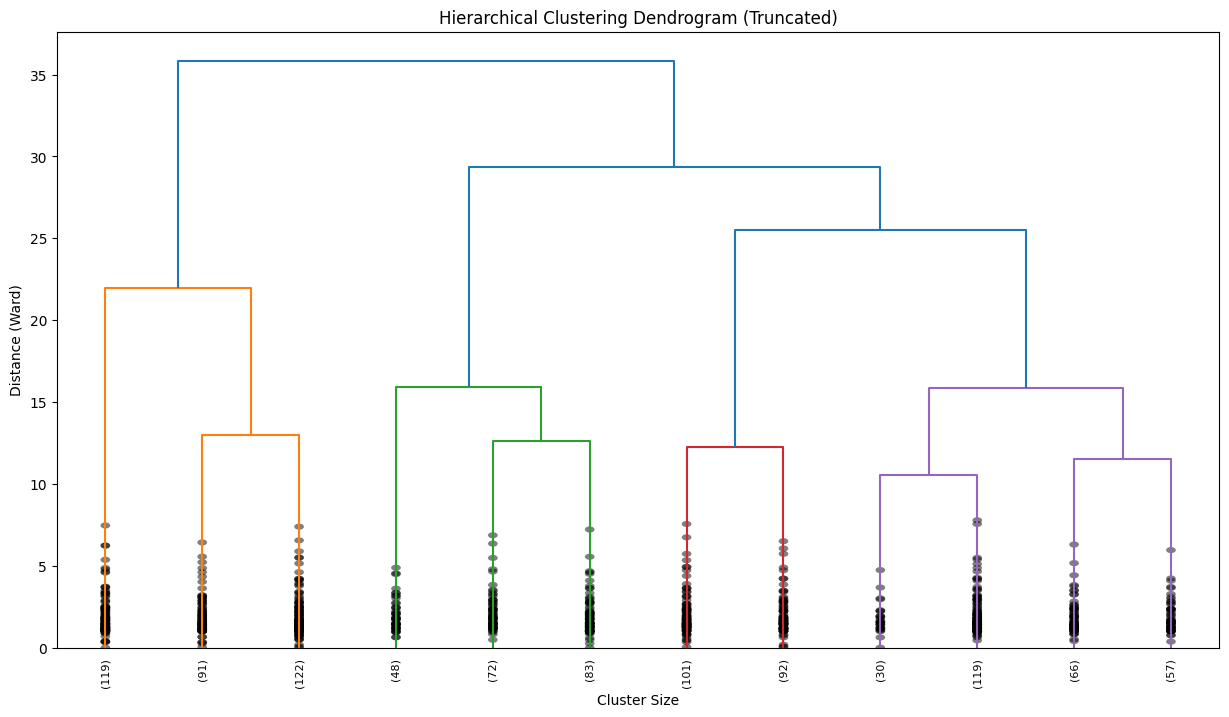

In [71]:
# --- Task 3.1: Build and Plot a Dendrogram ---
print("--- Task 3.1: Building Dendrogram ---")

# 'ward' linkage is a good default; it minimizes variance
# It's conceptually similar to k-means' inertia
linkage_matrix = linkage(X, method='ward', metric='euclidean')

# --- Plot the Dendrogram ---
plt.figure(figsize=(15, 8))
plt.title('Hierarchical Clustering Dendrogram (Truncated)')
plt.xlabel('Cluster Size')
plt.ylabel('Distance (Ward)')

dendrogram(
    linkage_matrix,
    truncate_mode='lastp',  # Show only the last p merged clusters
    p=12,                   # We'll show the last 12 merges
    leaf_rotation=90.,
    leaf_font_size=8.,
    show_contracted=True,   # To represent cluster sizes
)

plot_filename_dendro = 'lab6_dendrogram.png'
plt.savefig(plot_filename_dendro)
print(f"Dendrogram saved as: {plot_filename_dendro}")
plt.show()

In [72]:
%pip install mlxtend

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

Note: you may need to restart the kernel to use updated packages.


In [73]:
transactions = []
with open('groceries.csv', 'r') as file:
    for line in file:
        transactions.append(line.strip().split(','))

print("--- First 5 Transactions (as list) ---")
print(transactions[:5])

te = TransactionEncoder()
te_ary = te.fit_transform(transactions)
df_onehot = pd.DataFrame(te_ary, columns=te.columns_)

print("\n--- Processed One-Hot Encoded DataFrame (Head) ---")
print(df_onehot.head())

--- First 5 Transactions (as list) ---
[['bread', 'milk', 'eggs'], ['bread', 'diapers', 'beer'], ['milk', 'diapers', 'apples'], ['bread', 'milk', 'diapers', 'beer'], ['bread', 'milk', 'apples']]

--- Processed One-Hot Encoded DataFrame (Head) ---
   apples  bacon  bananas   beer  bread  butter  cereal  cheese  chips   cola  \
0   False  False    False  False   True   False   False   False  False  False   
1   False  False    False   True   True   False   False   False  False  False   
2    True  False    False  False  False   False   False   False  False  False   
3   False  False    False   True   True   False   False   False  False  False   
4    True  False    False  False   True   False   False   False  False  False   

   diapers   eggs    jam  juice   milk  shampoo   soap  
0    False   True  False  False   True    False  False  
1     True  False  False  False  False    False  False  
2     True  False  False  False   True    False  False  
3     True  False  False  False   True

In [74]:
frequent_itemsets_fp = fpgrowth(
    df_onehot, 
    min_support=0.2, 
    use_colnames=True
)

frequent_itemsets_fp = frequent_itemsets_fp.sort_values(
    by='support', 
    ascending=False
)

print("\n--- Frequent Itemsets (FP-Growth) (Support >= 0.2) ---")
print(frequent_itemsets_fp)


--- Frequent Itemsets (FP-Growth) (Support >= 0.2) ---
     support                itemsets
0   0.787671                  (milk)
1   0.630137                 (bread)
3   0.595890               (diapers)
8   0.506849         (diapers, milk)
6   0.424658           (milk, bread)
7   0.294521        (diapers, bread)
4   0.253425                  (beer)
2   0.219178                  (eggs)
5   0.219178                (apples)
9   0.212329  (diapers, milk, bread)
10  0.212329         (diapers, beer)
11  0.205479           (beer, bread)
12  0.205479          (milk, apples)


In [75]:
rules = association_rules(
    frequent_itemsets_fp, 
    metric='confidence', 
    min_threshold=0.6
)

# Sort by 'lift' to find the most interesting rules
rules = rules.sort_values(by='lift', ascending=False)

print("\n--- Association Rules (Confidence >= 0.6) ---")
print(rules)


--- Association Rules (Confidence >= 0.6) ---
        antecedents consequents  antecedent support  consequent support  \
4            (beer)   (diapers)            0.253425            0.595890   
5            (beer)     (bread)            0.253425            0.630137   
6          (apples)      (milk)            0.219178            0.787671   
0         (diapers)      (milk)            0.595890            0.787671   
1            (milk)   (diapers)            0.787671            0.595890   
3  (diapers, bread)      (milk)            0.294521            0.787671   
2           (bread)      (milk)            0.630137            0.787671   

    support  confidence      lift  representativity  leverage  conviction  \
4  0.212329    0.837838  1.406027               1.0  0.061315    2.492009   
5  0.205479    0.810811  1.286722               1.0  0.045787    1.954990   
6  0.205479    0.937500  1.190217               1.0  0.032839    3.397260   
0  0.506849    0.850575  1.079860           